# Notebook IV.4 — Frecuencia desconocida y condición de fase

Este notebook acompaña la **Ventana computacional IV.4** del Capítulo IV.

Aquí estudiamos una situación distinta a la del oscilador forzado: una **oscilación autónoma** cuya frecuencia no está dada de antemano, sino que debe resolverse junto con los coeficientes armónicos.

La idea central es mostrar que, al buscar una órbita periódica autónoma, aparece una indeterminación natural asociada a las **traslaciones temporales**. Para eliminarla, se introduce una **condición de fase**.

## Ejecutar este notebook en Google Colab

[![Run in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ricomelgozajjesus/monografia-armonica/blob/main/python-lab/notebooks/Notebook_IV_04_Frecuencia_desconocida.ipynb)

## 1. Modelo: oscilador de Van der Pol

Trabajaremos con la ecuación

$$
\ddot{x} - \mu(1-x^2)\dot{x} + x = 0,
$$

que puede escribirse como

$$
\ddot{x} + x - \mu(1-x^2)\dot{x} = 0.
$$

Se trata de un sistema autónomo con ciclo límite.  
A diferencia del caso forzado, aquí la frecuencia de la oscilación no es un dato impuesto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## 2. Parámetros y truncación armónica

Usaremos una expansión con armónicos impares

$$
x(\theta) \approx \sum_{k\in\{1,3,\dots\}} \big(a_k\cos(k\theta)+b_k\sin(k\theta)\big),
$$

donde $\theta=\omega t$ y $\omega$ es ahora una incógnita adicional.

In [2]:
mu = 1.0
harmonics = [1, 3, 5]
n_points = 2048

## 3. Coordenada angular y residual

Al introducir $\theta=\omega t$, se tiene

$$
\frac{dx}{dt} = \omega \frac{dx}{d\theta},
\qquad
\frac{d^2x}{dt^2} = \omega^2 \frac{d^2x}{d\theta^2}.
$$

Por tanto, la ecuación se convierte en

$$
\omega^2 x_{\theta\theta} + x - \mu(1-x^2)\,\omega x_\theta = 0.
$$

El residual se proyectará sobre la base trigonométrica retenida.  
Las incógnitas serán ahora:
- los coeficientes armónicos,
- la frecuencia $\omega$.

In [3]:
def build_theta_grid(n_points=1024):
    return np.linspace(0.0, 2*np.pi, n_points, endpoint=False)

def unpack_coeffs(c, harmonics):
    coeffs = {}
    for i, k in enumerate(harmonics):
        coeffs[k] = (c[2*i], c[2*i + 1])
    return coeffs

def reconstruct_theta_signal(c, harmonics, theta):
    x = np.zeros_like(theta, dtype=float)
    x_theta = np.zeros_like(theta, dtype=float)
    x_thetatheta = np.zeros_like(theta, dtype=float)

    coeffs = unpack_coeffs(c, harmonics)
    for k in harmonics:
        a, b = coeffs[k]
        ck = np.cos(k*theta)
        sk = np.sin(k*theta)
        x += a*ck + b*sk
        x_theta += -k*a*sk + k*b*ck
        x_thetatheta += -(k**2)*(a*ck + b*sk)

    return x, x_theta, x_thetatheta

## 4. Residual proyectado con frecuencia desconocida

Construimos el residual temporal en la variable $\theta$ y lo proyectamos sobre cada armónico retenido.

Además agregaremos una **condición de fase**.  
Aquí usaremos una elección simple:

$$
b_1 = 0.
$$

Esta condición fija la fase del armónico fundamental y elimina la libertad de desplazar la solución en el tiempo.

In [7]:
def residual_unknown_frequency(y, harmonics, mu, n_points=2048):
    # y = [a1,b1,a3,b3,...,omega]
    c = np.array(y[:-1], dtype=float)
    omega = float(y[-1])

    theta = build_theta_grid(n_points=n_points)
    x, x_theta, x_thetatheta = reconstruct_theta_signal(c, harmonics, theta)

    r = omega**2 * x_thetatheta + x - mu * (1 - x**2) * omega * x_theta

    R = []
    for k in harmonics:
        ck = np.cos(k*theta)
        sk = np.sin(k*theta)
        Rc = (2.0 / len(theta)) * np.sum(r * ck)
        Rs = (2.0 / len(theta)) * np.sum(r * sk)
        R.extend([Rc, Rs])

    # Agregamos la condición de fase como una ecuación adicional: b1 = 0
    # El índice de b1 es 1 en el vector 'c'
    R.append(c[1]) # Now R has 2*len(harmonics) + 1 equations

    return np.array(R, dtype=float)

## 5. Nota importante sobre la condición de fase

En un problema autónomo, si $x(t)$ es solución periódica, también lo es $x(t+\tau)$ para cualquier desplazamiento temporal $\tau$.  
Esa simetría implica una indeterminación en la representación armónica.

La condición de fase no elimina soluciones físicas; solo selecciona un representante único dentro de una familia temporalmente equivalente.

## 6. Jacobiano numérico y Newton–Raphson

In [8]:
def numerical_jacobian(fun, y, eps=1e-7):
    y = np.array(y, dtype=float)
    f0 = fun(y)
    J = np.zeros((len(f0), len(y)), dtype=float)
    for j in range(len(y)):
        yp = y.copy()
        ym = y.copy()
        yp[j] += eps
        ym[j] -= eps
        fp = fun(yp)
        fm = fun(ym)
        J[:, j] = (fp - fm) / (2*eps)
    return J

def newton_unknown_frequency(fun, y0, tol=1e-10, max_iter=25):
    y = np.array(y0, dtype=float)
    history = []

    for k in range(max_iter):
        R = fun(y)
        nr = np.linalg.norm(R)
        history.append((k, y.copy(), nr))
        if nr < tol:
            return y, history, True
        J = numerical_jacobian(fun, y)
        delta = np.linalg.solve(J, -R)
        y = y + delta

    R = fun(y)
    history.append((max_iter, y.copy(), np.linalg.norm(R)))
    return y, history, False

## 7. Elegir semilla inicial

Para un ciclo casi sinusoidal, una semilla razonable puede ser:
- amplitud fundamental dominante,
- armónicos superiores pequeños,
- frecuencia cercana a 1.

In [9]:
# [a1, b1, a3, b3, a5, b5, omega]
y0 = np.array([2.0, 0.0, 0.05, 0.0, 0.01, 0.0, 1.0], dtype=float)

fun = lambda y: residual_unknown_frequency(y, harmonics, mu, n_points=n_points)
sol, history, converged = newton_unknown_frequency(fun, y0, tol=1e-10, max_iter=20)

print("Convergió:", converged)
print("Norma final del residual:", history[-1][2])
print("Solución:", sol)

Convergió: True
Norma final del residual: 2.623872624760804e-12
Solución: [ 2.01484733e+00  3.00466889e-22 -8.49510446e-02 -2.22207513e-01
 -3.81423722e-02  3.28333824e-02  9.42942360e-01]


In [10]:
coeffs_sol = sol[:-1]
omega_sol = sol[-1]

print("Frecuencia estimada omega =", omega_sol)
print("Periodo estimado T =", 2*np.pi / omega_sol)

Frecuencia estimada omega = 0.942942360045505
Periodo estimado T = 6.663382167788463


## 8. Historial de convergencia

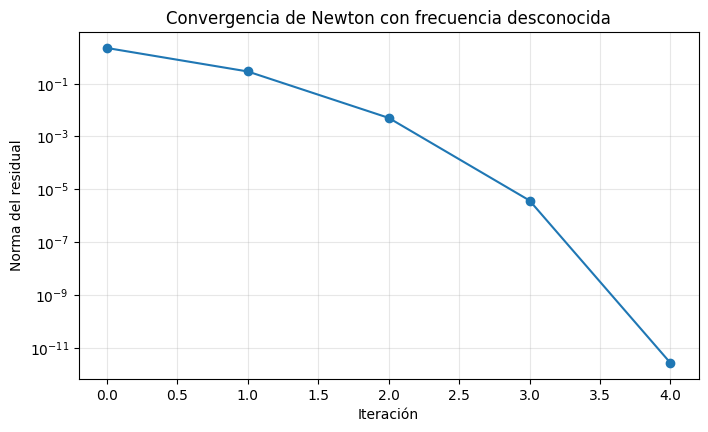

In [11]:
iters = [row[0] for row in history]
norms = [row[2] for row in history]

plt.figure(figsize=(8, 4.5))
plt.semilogy(iters, norms, marker="o")
plt.xlabel("Iteración")
plt.ylabel("Norma del residual")
plt.title("Convergencia de Newton con frecuencia desconocida")
plt.grid(True, alpha=0.3)
plt.show()

## 9. Reconstrucción de la órbita periódica

Con los coeficientes armónicos y la frecuencia estimada, podemos reconstruir la solución aproximada.

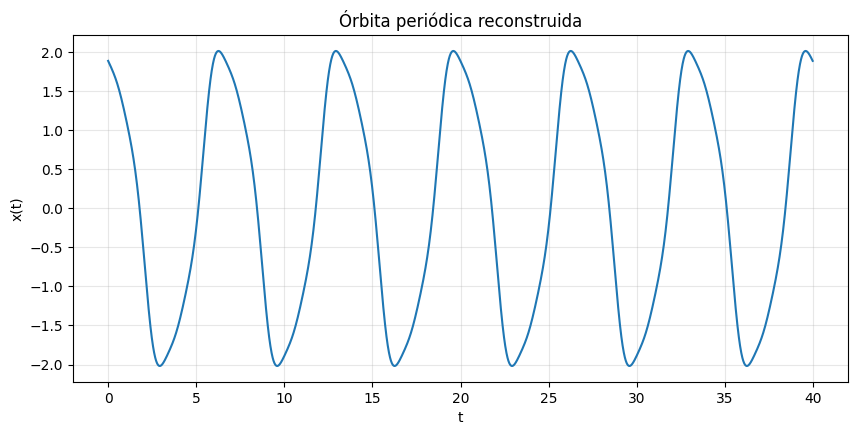

In [12]:
theta = np.linspace(0, 6*2*np.pi, 4000)
x_theta, x_dtheta, x_ddtheta = reconstruct_theta_signal(coeffs_sol, harmonics, theta)

# Convertimos derivada con respecto a theta a derivada temporal:
x_dot = omega_sol * x_dtheta

t_plot = theta / omega_sol

plt.figure(figsize=(10, 4.5))
plt.plot(t_plot, x_theta)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Órbita periódica reconstruida")
plt.grid(True, alpha=0.3)
plt.show()

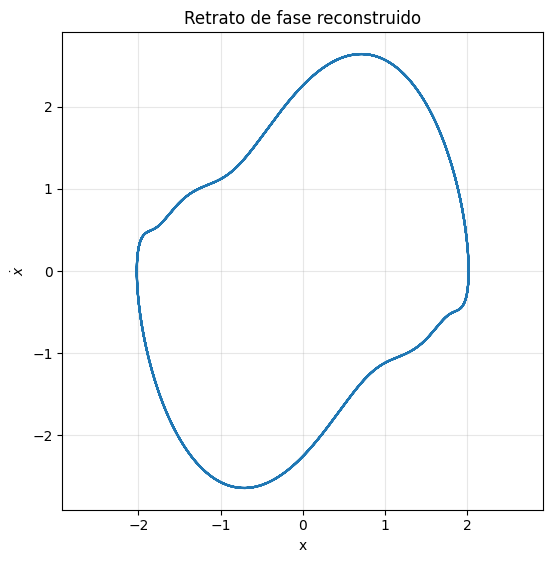

In [13]:
plt.figure(figsize=(6.2, 6.2))
plt.plot(x_theta, x_dot)
plt.xlabel("x")
plt.ylabel(r"$\dot{x}$")
plt.title("Retrato de fase reconstruido")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

## 10. Amplitudes armónicas estimadas

In [14]:
def amplitude_spectrum_from_coeffs(c, harmonics):
    amps = {}
    coeffs = unpack_coeffs(c, harmonics)
    for k in harmonics:
        a, b = coeffs[k]
        amps[k] = np.sqrt(a*a + b*b)
    return amps

amps = amplitude_spectrum_from_coeffs(coeffs_sol, harmonics)

print("Orden armónico | Amplitud")
print("-" * 28)
for k in harmonics:
    print(f"{k:15d} | {amps[k]:.8f}")

Orden armónico | Amplitud
----------------------------
              1 | 2.01484733
              3 | 0.23789254
              5 | 0.05032764


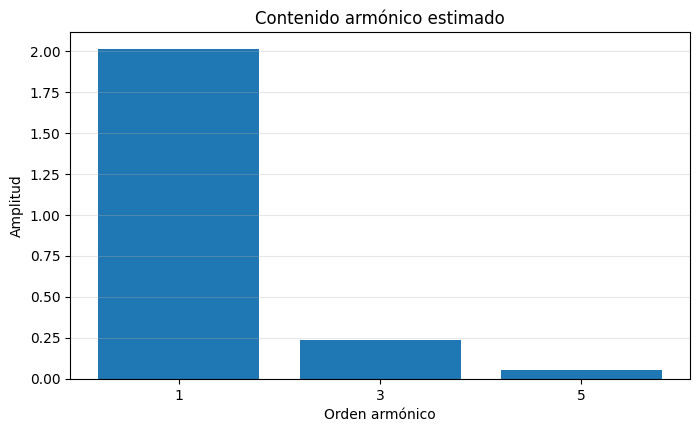

In [15]:
orders = harmonics
values = [amps[k] for k in orders]

plt.figure(figsize=(8, 4.5))
plt.bar([str(k) for k in orders], values)
plt.xlabel("Orden armónico")
plt.ylabel("Amplitud")
plt.title("Contenido armónico estimado")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 11. Comparación con integración temporal directa

Para dar contexto, integramos numéricamente el sistema de Van der Pol y comparamos la órbita resultante con la reconstrucción armónica.

In [16]:
def vdp_rhs(t, y, mu):
    x, v = y
    dxdt = v
    dvdt = mu*(1 - x**2)*v - x
    return [dxdt, dvdt]

t_eval = np.linspace(0, 200, 40000)
sol_ivp = solve_ivp(
    vdp_rhs,
    (0.0, 200.0),
    [1.0, 0.0],
    t_eval=t_eval,
    args=(mu,),
    rtol=1e-8,
    atol=1e-10
)

t_full = sol_ivp.t
x_full = sol_ivp.y[0]
v_full = sol_ivp.y[1]

# Nos quedamos con la cola para aproximar el ciclo límite
keep = 8000
t_ss = t_full[-keep:]
x_ss = x_full[-keep:]
v_ss = v_full[-keep:]

# Reescalamos el tiempo reconstruido para mostrar varias oscilaciones
t_compare = t_plot
x_compare = x_theta

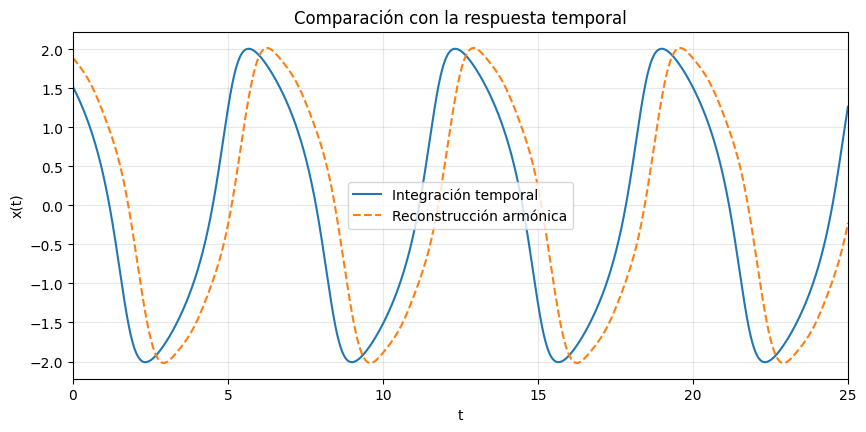

In [17]:
plt.figure(figsize=(10, 4.5))
plt.plot(t_ss - t_ss[0], x_ss, label="Integración temporal")
plt.plot(t_compare, x_compare, "--", label="Reconstrucción armónica")
plt.xlim(0, min((t_ss[-1] - t_ss[0]), t_compare[-1], 25))
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Comparación con la respuesta temporal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 12. Interpretación

Este notebook ilustra varias ideas centrales:

- en una oscilación autónoma, la frecuencia forma parte de la incógnita;
- la representación armónica introduce una indeterminación de fase ligada a la invariancia temporal;
- la condición de fase no restringe artificialmente la solución, sino que selecciona una representación única;
- resolver simultáneamente coeficientes y frecuencia es una extensión natural del balance armónico.

Así, el paso desde el caso forzado al caso autónomo revela con mayor claridad la geometría subyacente de las órbitas periódicas.

## 13. Exploraciones sugeridas

1. Cambia el parámetro `mu` y observa cómo cambia la frecuencia estimada.
2. Añade más armónicos a la truncación.
3. Modifica la semilla inicial `y0` y estudia la robustez de Newton.
4. Prueba otras condiciones de fase.
5. Compara con mayor cuidado la órbita temporal y la reconstrucción armónica.

## 14. Hacia el siguiente notebook

El siguiente paso natural es volver al contexto eléctrico y estudiar una **corriente no sinusoidal**, su **espectro** y un índice básico de distorsión como el **THD**, preparando así la entrada al pequeño laboratorio armónico en sistemas eléctricos.